In [204]:
from pydrake.all import (LeafSystem, BasicVector, DiagramBuilder, LinearSystem,
                           LogVectorOutput, Simulator, ConstantVectorSource,
                            MatrixGain, VectorSystem, ModelVisualizer)
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.linalg as linalg
import control as ctr
import pydot

In [194]:
dt = 0.05

DT_Motor_A = np.array([[0, 1],
                        [-0.552, 1.52]])
DT_Motor_B = np.array([[0],
                        [1]])
DT_Motor_C = np.array([[0.00164, 0.002]])
DT_Motor_D = np.array([[0]])

DTMotro_ss = ctr.ss(DT_Motor_A, DT_Motor_B, DT_Motor_C, DT_Motor_D, dt)
DTMotor_tf = ctr.ss2tf(DTMotro_ss)

In [195]:
print(DTMotor_tf)

<TransferFunction>: sys[21]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

   0.002 z + 0.00164
  --------------------
  z^2 - 1.52 z + 0.552


In [196]:
class DT_PISys(LeafSystem):
    def __init__(self, kp=0.5, ki=0.3, dt=0.05):
        super().__init__()
        self._ki = ki
        self._kp = kp
        self._dt = dt
        self._reference = self.DeclareVectorInputPort("r", 1)
        self._y = self.DeclareVectorInputPort("y", 1)
        self.DeclareDiscreteState(1)
        self.DeclareVectorOutputPort("u", 1, self.CalcControl)
    def DoCalcDiscreteVariableUpdates(self, context, discrete_state):
        x_k = context.get_discrete_state_vector().CopyToVector()
        r_k = self._reference.Eval(context)[0]
        y_k = self._y.Eval(context)[0]
        xnext = x_k + (r_k - y_k)  * self._dt
        discrete_state.get_mutable_vector().SetFromVector(xnext)
    def CalcControl(self, context, output):
        x_k = context.get_discrete_state_vector().CopyToVector()
        r_k = self._reference.Eval(context)[0]
        y_k = self._y.Eval(context)[0]
        u_k = self._kp * (r_k - y_k) + self._ki * x_k
        output.SetFromVector([u_k])
        

Text(0.5, 1.0, 'Motor Position Response with PI Control')

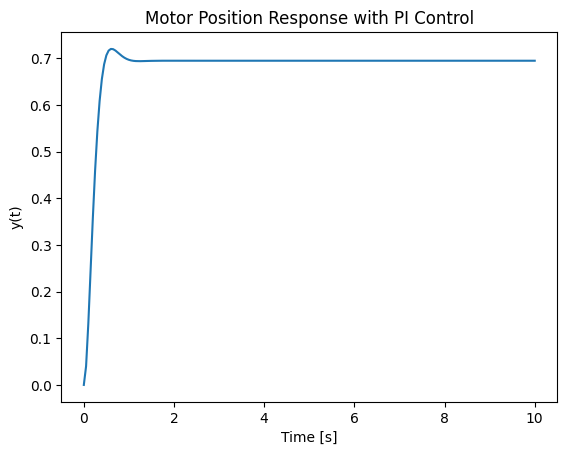

In [197]:
builder = DiagramBuilder()
# add subsystems
motor = builder.AddSystem(LinearSystem(DT_Motor_A, DT_Motor_B, DT_Motor_C, DT_Motor_D, dt))
pi_controller = builder.AddSystem(DT_PISys(kp=20, ki=20, dt=dt))
Constant_ref  = builder.AddSystem(ConstantVectorSource(np.array([1.0])))
# add conncetions
builder.Connect(pi_controller.get_output_port(0), motor.get_input_port(0))
builder.Connect(motor.get_output_port(0), pi_controller.get_input_port(1))
builder.Connect(Constant_ref.get_output_port(0), pi_controller.get_input_port(0))
# log output
logger = LogVectorOutput(motor.get_output_port(0), builder)

diagram = builder.Build()
simulator = Simulator(diagram)

# set the initial condition
context = simulator.get_mutable_context()

motor_context = diagram.GetSubsystemContext(motor, context)
motor_context.SetDiscreteState([0.0, 0.0])

pi_controller_context = diagram.GetSubsystemContext(pi_controller, context)
pi_controller_context.SetDiscreteState([0.0])


simulator.AdvanceTo(10)



# Then plot
log = logger.FindLog(context)
plt.figure()
plt.plot(log.sample_times(), log.data().transpose())
plt.xlabel('Time [s]')
plt.ylabel('y(t)')
plt.title('Motor Position Response with PI Control')

## Robust tracking design method 

In [198]:
Atilde = np.block([[DT_Motor_A, np.zeros((DT_Motor_A.shape[0], 1))],
                   [-DT_Motor_C, np.eye(1)]])
Btilde = np.vstack([DT_Motor_B, 0])

Mctilde = np.hstack([Btilde, Atilde @ Btilde, Atilde @ Atilde @ Btilde])
Mc      = np.hstack([DT_Motor_B, DT_Motor_A @ DT_Motor_B, DT_Motor_A @ DT_Motor_A @ DT_Motor_B])

print(np.linalg.matrix_rank(Mctilde))
print(np.linalg.matrix_rank(Mc))

3
2


In [199]:
s_d = np.array([-15, -10 + 1j, -10 - 1j])
z_d = np.exp(s_d * dt)

Ktilde = signal.place_poles(Atilde, Btilde, z_d).gain_matrix
print(Ktilde)
print(Ktilde[0, :2])


[[ -0.34106153   0.83608814 -22.66129595]]
[-0.34106153  0.83608814]


In [200]:
class TrackingController(LeafSystem):
    def __init__(self, Ktilde, C_matrix, dt=0.05):
        super().__init__()
        self._Ktilde = Ktilde
        self._C_matrix = C_matrix
        self._dt = dt
        # inputs ports
        self._reference = self.DeclareVectorInputPort("r", 1)
        self._motor_state = self.DeclareVectorInputPort("motor_state", 2)
        # state
        self.DeclareDiscreteState(1)
        # output port
        self.DeclareVectorOutputPort("u", 1, self.CalcControl)

        self.DeclarePeriodicDiscreteUpdateEvent(
            period_sec=self._dt,
            offset_sec=0.0,
            update=self.DoCalcDiscreteVariableUpdates
        )

    def DoCalcDiscreteVariableUpdates(self, context, discrete_state):
        x_k = context.get_discrete_state_vector().CopyToVector()
        r_k = self._reference.Eval(context)
        plant_x = self._motor_state.Eval(context)
        plant_y = self._C_matrix @ plant_x.reshape(-1, 1)
        xnext = x_k + (r_k - plant_y)
        discrete_state.get_mutable_vector().SetFromVector(xnext)

    def CalcControl(self, context, output):
        x_k = context.get_discrete_state_vector().CopyToVector()
        plant_x = self._motor_state.Eval(context)
        xtilde = np.vstack([plant_x.reshape(2, 1), x_k])
        u_k = self._Ktilde @ xtilde
        output.SetFromVector(u_k)

Diagram saved as 'control_diagram.svg'


Text(0.5, 1.0, 'Motor Position Response with State Feedback Control')

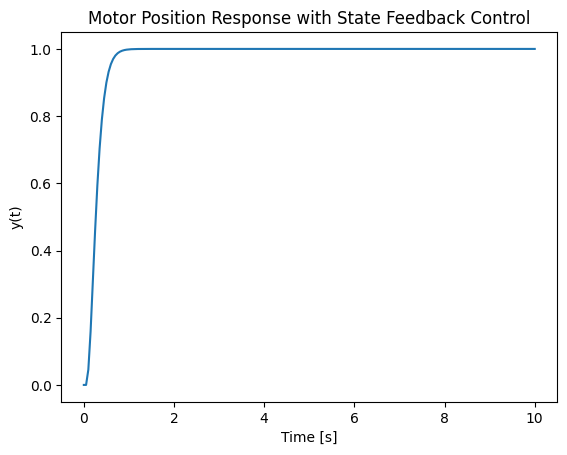

In [ ]:
builder = DiagramBuilder()
# add subsystems
motor = builder.AddSystem(LinearSystem(DT_Motor_A, DT_Motor_B, np.eye(2), np.zeros((2, 1)), dt))
tracking_controller = builder.AddSystem(TrackingController(-Ktilde, DT_Motor_C, dt= dt))
Constant_ref  = builder.AddSystem(ConstantVectorSource(np.array([1.0])))
C_matrix = builder.AddSystem(MatrixGain(DT_Motor_C))

# add connections
builder.Connect(tracking_controller.get_output_port(0), motor.get_input_port(0))
builder.Connect(Constant_ref.get_output_port(0), tracking_controller.get_input_port(0))
builder.Connect(motor.get_output_port(0), tracking_controller.get_input_port(1))
builder.Connect(motor.get_output_port(0), C_matrix.get_input_port(0))

# log output
logger = LogVectorOutput(C_matrix.get_output_port(0), builder)

diagram = builder.Build()

# ===== VISUALIZE THE DIAGRAM =====
graphviz_str = diagram.GetGraphvizString()
graphs = pydot.graph_from_dot_data(graphviz_str)
graph = graphs[0]
graph.write_svg('control_diagram.svg')
print("Diagram saved as 'control_diagram.svg'")

simulator = Simulator(diagram)

# set the initial condition
context = simulator.get_mutable_context()

motor_context = diagram.GetSubsystemContext(motor, context)
motor_context.SetDiscreteState([0.0, 0.0])

tracking_controller_context = diagram.GetSubsystemContext(tracking_controller, context)
tracking_controller_context.SetDiscreteState([0.0])

simulator.AdvanceTo(10)

# Then plot
log = logger.FindLog(context)
plt.figure()
plt.plot(log.sample_times(), log.data().transpose())
plt.xlabel('Time [s]')
plt.ylabel('y(t)')
plt.title('Motor Position Response with State Feedback Control')
